11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000, Test samples: 10000
Input dimension: 784
Noise factor: 0.5  |  Noisy train shape: (60000, 784)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0656 - val_loss: 0.0432
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0376 - val_loss: 0.0330
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0314 - val_loss: 0.0291
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0282 - val_loss: 0.0268
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0266 - val_loss: 0.0255
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0253 - val_loss: 0.0245
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0244 - val_loss: 0.0239
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0237 - val_loss: 0.0231
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0232 - val_loss: 0.0227
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0227 - val_loss: 0.0223
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0223 - val_loss: 0.0220
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

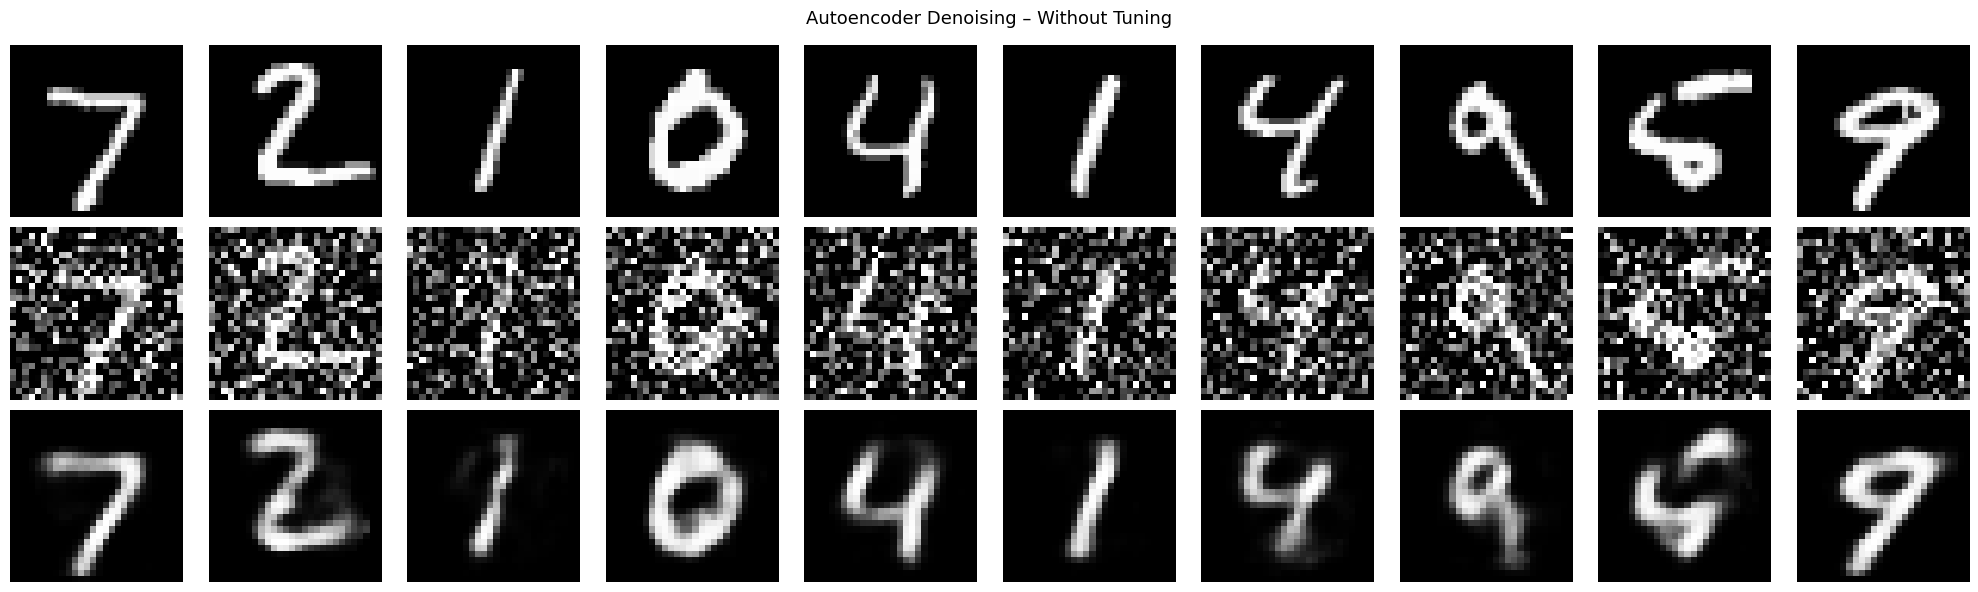

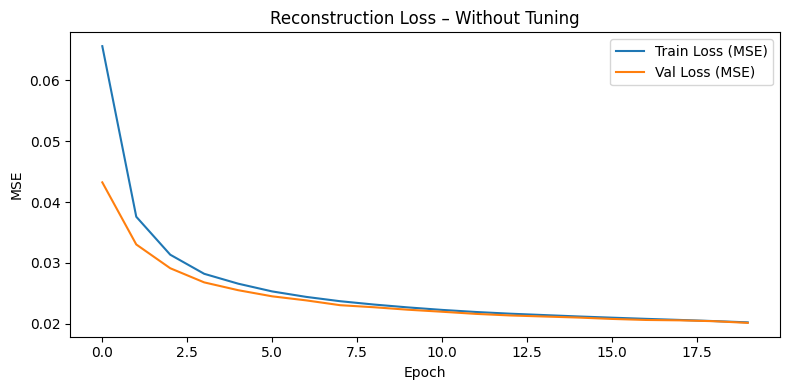

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

# Load MNIST
(X_train, _), (X_test, _) = keras.datasets.mnist.load_data()

# Normalize and flatten
X_train = X_train.astype('float32').reshape(-1, 784) / 255.0
X_test  = X_test.astype('float32').reshape(-1, 784)  / 255.0

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Input dimension: {X_train.shape[1]}")

# Add Gaussian noise
noise_factor = 0.5
X_train_noisy = np.clip(X_train + noise_factor * np.random.normal(0, 1, X_train.shape), 0.0, 1.0)
X_test_noisy  = np.clip(X_test  + noise_factor * np.random.normal(0, 1, X_test.shape),  0.0, 1.0)

print(f"Noise factor: {noise_factor}  |  Noisy train shape: {X_train_noisy.shape}")

# Build Autoencoder
input_img = keras.Input(shape=(784,))

# Encoder
x = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(32, activation='relu')(x)

# Decoder
x = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(x)

autoencoder = keras.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Train: noisy input → clean output
history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=20, batch_size=256,
    validation_data=(X_test_noisy, X_test),
    verbose=1
)

# Evaluate
test_mse = autoencoder.evaluate(X_test_noisy, X_test, verbose=0)
print(f"\nTest Reconstruction MSE: {test_mse:.6f}")

# Visualize: original / noisy / denoised
decoded_imgs = autoencoder.predict(X_test_noisy[:10])

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
titles = ['Original', 'Noisy (Input)', 'Denoised (Output)']
rows   = [X_test[:10], X_test_noisy[:10], decoded_imgs]
for r, (row_data, title) in enumerate(zip(rows, titles)):
    for i in range(10):
        axes[r, i].imshow(row_data[i].reshape(28, 28), cmap='gray')
        axes[r, i].axis('off')
    axes[r, 0].set_ylabel(title, fontsize=11)
plt.suptitle('Autoencoder Denoising – Without Tuning', fontsize=13)
plt.tight_layout()
plt.show()

# Loss curves
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Reconstruction Loss – Without Tuning')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout()
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.7 MB/s eta 0:00:00
Starting hyperparameter search (10 trials)...

Best Hyperparameters:
  encoding_dim  : 32
  hidden_units  : 128
  learning_rate : 0.001
Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0652 - val_loss: 0.0417
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0378 - val_loss: 0.0336
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0313 - val_loss: 0.0286
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0276 - val_loss: 0.0262
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0259 - val_loss: 0.0251
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0248 - val_loss: 0.0240
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0239 - val_loss: 0.0232
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0231 - val_loss: 0.0225
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0225 - val_loss: 0.0220
E

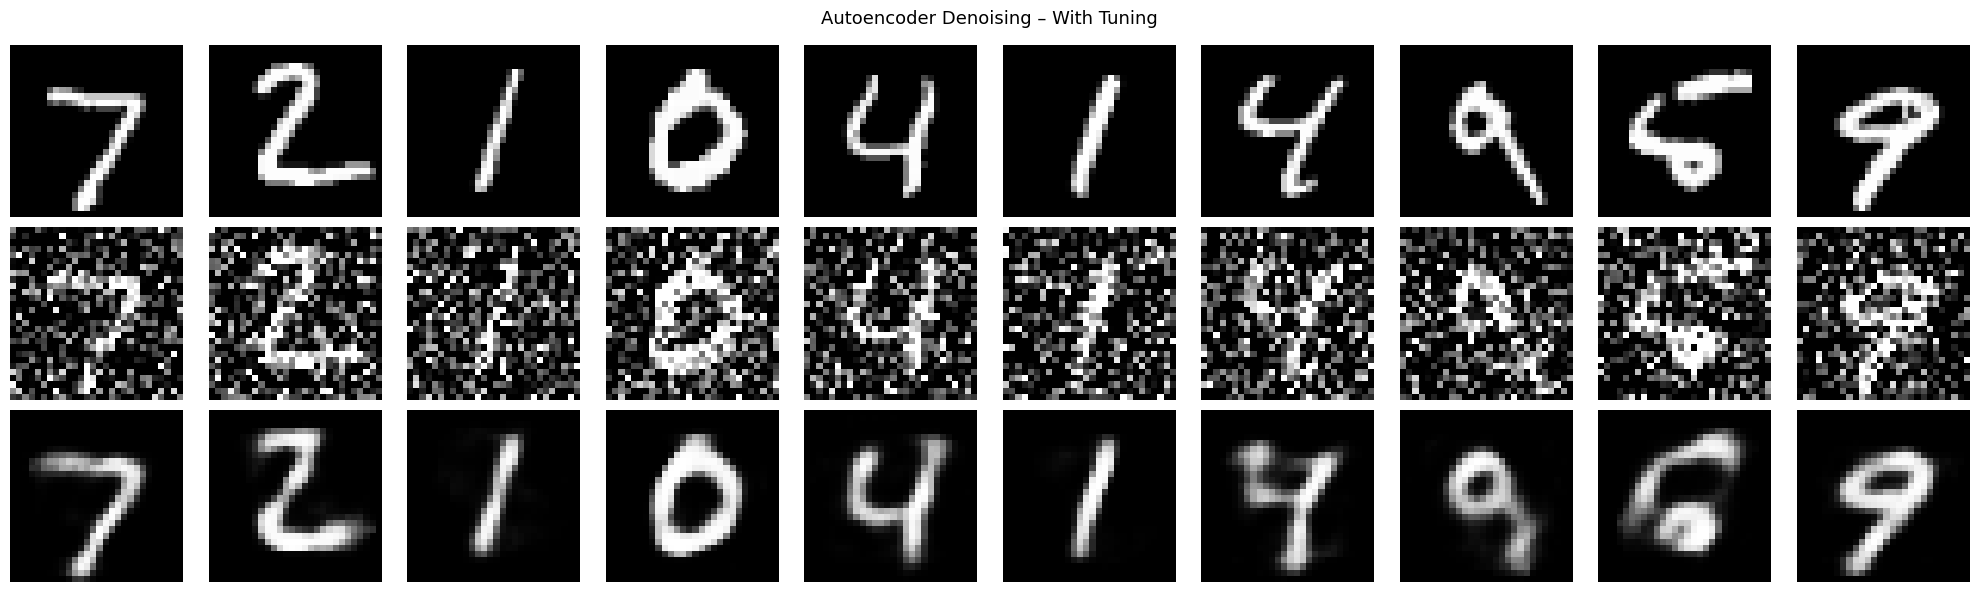

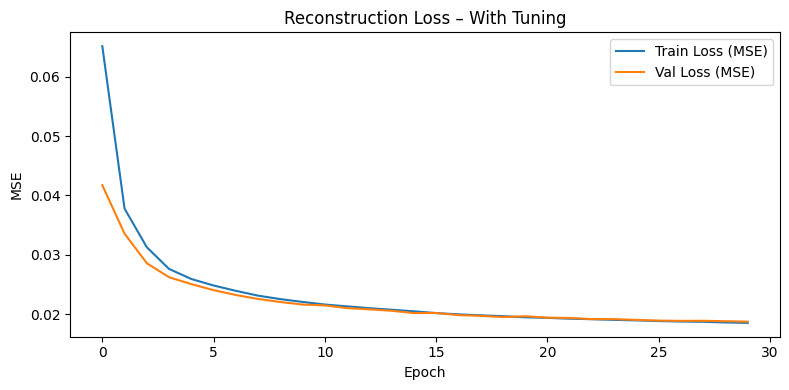

In [2]:
!pip install keras-tuner -q

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

# Load and preprocess
(X_train, _), (X_test, _) = keras.datasets.mnist.load_data()
X_train = X_train.astype('float32').reshape(-1, 784) / 255.0
X_test  = X_test.astype('float32').reshape(-1, 784)  / 255.0

noise_factor = 0.5
X_train_noisy = np.clip(X_train + noise_factor * np.random.normal(0, 1, X_train.shape), 0.0, 1.0)
X_test_noisy  = np.clip(X_test  + noise_factor * np.random.normal(0, 1, X_test.shape),  0.0, 1.0)

def build_autoencoder(hp):
    enc_dim = hp.Choice('encoding_dim',  [16, 32, 64])
    hidden  = hp.Choice('hidden_units',  [64, 128, 256])
    lr      = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])

    input_img = keras.Input(shape=(784,))
    x = layers.Dense(hidden,  activation='relu')(input_img)
    x = layers.Dense(enc_dim, activation='relu')(x)       # bottleneck
    x = layers.Dense(hidden,  activation='relu')(x)
    output = layers.Dense(784, activation='sigmoid')(x)

    model = keras.Model(input_img, output)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

tuner = kt.RandomSearch(
    build_autoencoder,
    objective='val_loss',        # minimize reconstruction MSE
    max_trials=10,
    seed=42,
    directory='ae_tuning',
    project_name='mnist_ae'
)

print("Starting hyperparameter search (10 trials)...")
tuner.search(
    X_train_noisy[:10000], X_train[:10000],
    epochs=10,
    validation_data=(X_test_noisy, X_test),
    verbose=0
)

best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print(f"  encoding_dim  : {best_hps.get('encoding_dim')}")
print(f"  hidden_units  : {best_hps.get('hidden_units')}")
print(f"  learning_rate : {best_hps.get('learning_rate')}")

# Retrain best model on full data
best_model = tuner.hypermodel.build(best_hps)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3,
                                            restore_best_weights=True)
history = best_model.fit(
    X_train_noisy, X_train,
    epochs=30, batch_size=256,
    validation_data=(X_test_noisy, X_test),
    callbacks=[early_stop], verbose=1
)

print(f"\nStopped at epoch: {len(history.history['loss'])}")

test_mse = best_model.evaluate(X_test_noisy, X_test, verbose=0)
print(f"Test Reconstruction MSE: {test_mse:.6f}")

# Visualize
decoded_imgs = best_model.predict(X_test_noisy[:10])

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
titles   = ['Original', 'Noisy (Input)', 'Denoised (Output)']
rows     = [X_test[:10], X_test_noisy[:10], decoded_imgs]
for r, (row_data, title) in enumerate(zip(rows, titles)):
    for i in range(10):
        axes[r, i].imshow(row_data[i].reshape(28, 28), cmap='gray')
        axes[r, i].axis('off')
    axes[r, 0].set_ylabel(title, fontsize=11)
plt.suptitle('Autoencoder Denoising – With Tuning', fontsize=13)
plt.tight_layout()
plt.show()

# Loss curves
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Reconstruction Loss – With Tuning')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend()
plt.tight_layout()
plt.show()
